# YOLO Person Gaussian Risk Map Test Notebook

YOLO 사람 검출 bbox를 이용해 아래 파이프라인을 노트북에서 바로 검증한다.

1. 사람 감지
2. bbox 중심으로 카메라 방향 계산
3. 로봇 pose 기준 map 좌표로 위험 spot 투영
4. Gaussian 확산 + 시간 감쇠
5. risk map / priority map 생성 및 시각화

기본 수식:

- $\theta_{world}=\psi_{robot}+\theta_{camera}$
- $\mu_x=x_{robot}+d\cos(\theta_{world})$
- $\mu_y=y_{robot}+d\sin(\theta_{world})$
- $G(x,y)=A\exp\left(-\frac{1}{2}\left[\frac{(x-\mu_x)^2}{\sigma_x^2}+\frac{(y-\mu_y)^2}{\sigma_y^2}\right]\right)$

In [12]:
import math
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import matplotlib.pyplot as plt

# ===== Section 1: 환경 설정 및 파라미터 =====
distance_mode = "fixed"        # "fixed" | "bbox_height"
fixed_distance_m = 2.0
gaussian_sigma_m = 0.60
gaussian_mode = "max"          # "max" | "sum"
decay = 0.98

# 맵 설정 (map frame)
resolution = 0.05               # meters/cell
width = 200                     # 10m
height = 200                    # 10m
origin_x = -5.0                 # world x of cell (0,0)
origin_y = -5.0                 # world y of cell (0,0)

# 카메라 파라미터(근사)
image_width_px = 1280
image_height_px = 720
camera_hfov_deg = 90.0

# bbox height 기반 거리 추정 기본 비활성
bbox_distance_enabled = False
person_real_height_m = 1.70
focal_length_px = 900.0

print("Parameters loaded")
print("distance_mode:", distance_mode)
print("fixed_distance_m:", fixed_distance_m)
print("gaussian_sigma_m:", gaussian_sigma_m)
print("gaussian_mode:", gaussian_mode)
print("decay:", decay)

Parameters loaded
distance_mode: fixed
fixed_distance_m: 2.0
gaussian_sigma_m: 0.6
gaussian_mode: max
decay: 0.98


## 2) 입력 데이터 구조 정의 (Detection, RobotPose)

ROS2 없이도 반복 검증할 수 있도록 샘플 프레임 시퀀스를 만든다.

In [13]:
@dataclass
class Detection:
    x1: float
    y1: float
    x2: float
    y2: float
    score: float
    class_id: int = 0

    @property
    def cx(self) -> float:
        return 0.5 * (self.x1 + self.x2)

    @property
    def cy(self) -> float:
        return 0.5 * (self.y1 + self.y2)

    @property
    def h(self) -> float:
        return max(1.0, self.y2 - self.y1)


@dataclass
class RobotPose:
    x: float
    y: float
    yaw: float  # rad


# 프레임별 샘플 데이터 (detection list, robot pose)
sample_sequence: List[Tuple[List[Detection], RobotPose]] = [
    ([Detection(560, 220, 700, 650, 0.90)], RobotPose(0.0, 0.0, 0.00)),
    ([Detection(620, 230, 770, 670, 0.92)], RobotPose(0.2, 0.0, 0.05)),
    ([Detection(680, 240, 840, 680, 0.91)], RobotPose(0.4, 0.05, 0.10)),
    ([Detection(760, 250, 930, 690, 0.88)], RobotPose(0.6, 0.10, 0.10)),
    ([Detection(520, 240, 680, 670, 0.86), Detection(820, 260, 980, 700, 0.84)], RobotPose(0.8, 0.15, 0.12)),
]

print("sample frames:", len(sample_sequence))

sample frames: 5


## 3) bbox 중심 -> 카메라 각도 변환

bbox 중심 x 픽셀을 이용해 수평 각도 $\theta_{camera}$를 구한다.

기본 경로는 `fixed_distance_m`를 사용하고, bbox height 기반 거리는 옵션으로 둔다.

In [14]:
def bbox_center_to_camera_angle(cx_px: float, img_w: int, hfov_deg: float) -> float:
    hfov = math.radians(hfov_deg)
    x_norm = (cx_px - (img_w * 0.5)) / (img_w * 0.5)
    # 소각 근사보다 안정적으로 tan inverse 방식 사용
    return math.atan(math.tan(hfov * 0.5) * x_norm)


def estimate_distance_from_bbox_height(det: Detection, focal_px: float, person_h_m: float) -> float:
    # 매우 거칠기 때문에 기본 비활성 권장
    return (person_h_m * focal_px) / max(det.h, 1.0)


def choose_distance(det: Detection) -> float:
    if distance_mode == "bbox_height" and bbox_distance_enabled:
        d = estimate_distance_from_bbox_height(det, focal_length_px, person_real_height_m)
        return float(np.clip(d, 0.8, 8.0))
    return fixed_distance_m

## 4) 카메라 각도 + 로봇 pose로 월드 위험 spot 투영

- $\theta_{world}=\psi_{robot}+\theta_{camera}$
- $\mu_x=x_{robot}+d\cos(\theta_{world})$
- $\mu_y=y_{robot}+d\sin(\theta_{world})$

In [15]:
def project_detection_to_world(det: Detection, pose: RobotPose) -> Tuple[float, float, float, float]:
    theta_camera = bbox_center_to_camera_angle(det.cx, image_width_px, camera_hfov_deg)
    theta_world = pose.yaw + theta_camera
    d = choose_distance(det)
    mu_x = pose.x + d * math.cos(theta_world)
    mu_y = pose.y + d * math.sin(theta_world)
    return mu_x, mu_y, theta_camera, theta_world

## 5) 2D Gaussian 위험도 커널 생성

월드 좌표와 맵 인덱스 변환 유틸리티를 포함한다.

In [16]:
def world_to_map(x: float, y: float) -> Tuple[int, int]:
    mx = int((x - origin_x) / resolution)
    my = int((y - origin_y) / resolution)
    return mx, my


def map_to_world(mx: int, my: int) -> Tuple[float, float]:
    x = origin_x + (mx + 0.5) * resolution
    y = origin_y + (my + 0.5) * resolution
    return x, y


class GaussianRiskMap:
    def __init__(self, width: int, height: int, resolution: float, origin_x: float, origin_y: float):
        self.width = width
        self.height = height
        self.resolution = resolution
        self.origin_x = origin_x
        self.origin_y = origin_y
        self.risk_map = np.zeros((height, width), dtype=np.float32)

        xs = origin_x + (np.arange(width) + 0.5) * resolution
        ys = origin_y + (np.arange(height) + 0.5) * resolution
        self.grid_x, self.grid_y = np.meshgrid(xs, ys)

    def decay_step(self, factor: float):
        self.risk_map *= float(np.clip(factor, 0.0, 1.0))

    def add_gaussian(self, mu_x: float, mu_y: float, sigma: float = 0.60, amplitude: float = 1.0, mode: str = "max"):
        if sigma <= 0:
            return
        dx = self.grid_x - mu_x
        dy = self.grid_y - mu_y
        g = amplitude * np.exp(-0.5 * ((dx * dx) / (sigma * sigma) + (dy * dy) / (sigma * sigma)))

        if mode == "sum":
            self.risk_map = np.clip(self.risk_map + g, 0.0, 1.0)
        else:
            self.risk_map = np.maximum(self.risk_map, g).astype(np.float32)

    def update_frame(self, detections: List[Detection], pose: RobotPose, sigma: float, mode: str, decay_factor: float):
        self.decay_step(decay_factor)
        spots = []
        for det in detections:
            if det.class_id != 0:
                continue
            mu_x, mu_y, theta_cam, theta_world = project_detection_to_world(det, pose)
            self.add_gaussian(mu_x, mu_y, sigma=sigma, amplitude=float(np.clip(det.score, 0.1, 1.0)), mode=mode)
            spots.append((mu_x, mu_y, theta_cam, theta_world, det.score))
        return spots


risk_engine = GaussianRiskMap(width, height, resolution, origin_x, origin_y)
print("Risk engine initialized")

Risk engine initialized


## 6) Risk Map 업데이트 모드 (`max` / `sum`)

한 프레임에서 다중 person detection을 순회 처리한다.

In [17]:
def run_sequence_once(mode: str = "max", decay_factor: float = 0.98, sigma: float = 0.60):
    engine = GaussianRiskMap(width, height, resolution, origin_x, origin_y)
    all_spots = []
    for dets, pose in sample_sequence:
        spots = engine.update_frame(dets, pose, sigma=sigma, mode=mode, decay_factor=decay_factor)
        all_spots.append(spots)
    return engine.risk_map.copy(), all_spots


risk_max, spots_max = run_sequence_once(mode="max", decay_factor=decay, sigma=gaussian_sigma_m)
risk_sum, spots_sum = run_sequence_once(mode="sum", decay_factor=decay, sigma=gaussian_sigma_m)

print("max mode final risk range:", float(risk_max.min()), float(risk_max.max()))
print("sum mode final risk range:", float(risk_sum.min()), float(risk_sum.max()))

max mode final risk range: 7.006492321624085e-45 0.873746931552887
sum mode final risk range: 6.817996830302027e-45 1.0


## 7) 시간 감쇠(`decay`) 프레임 루프 비교

`decay` 값에 따른 잔존 위험도 변화를 비교한다.

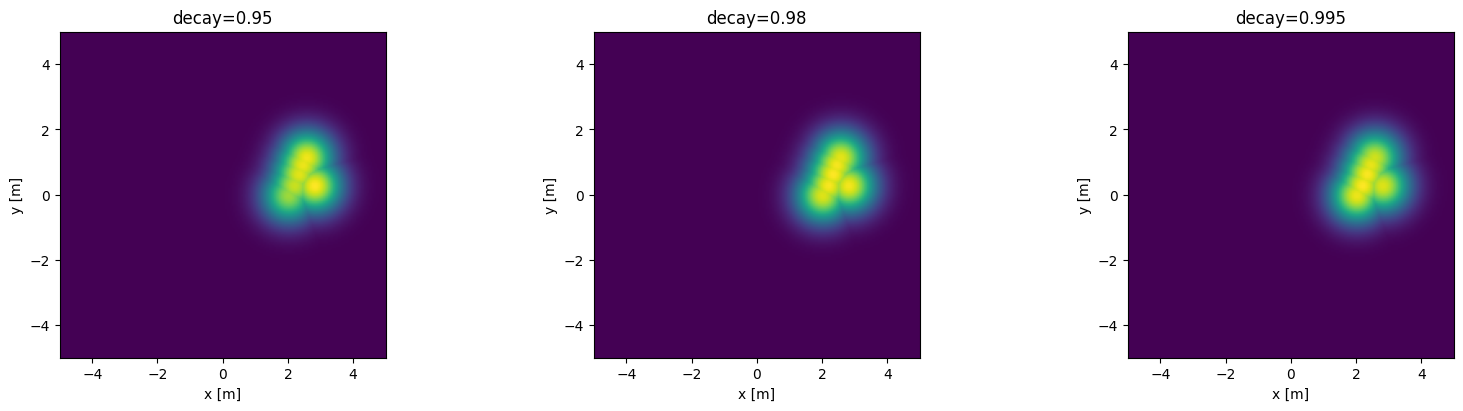

In [18]:
decay_candidates = [0.95, 0.98, 0.995]
compare_maps = {}
for dcy in decay_candidates:
    rm, _ = run_sequence_once(mode=gaussian_mode, decay_factor=dcy, sigma=gaussian_sigma_m)
    compare_maps[dcy] = rm

fig, axes = plt.subplots(1, len(decay_candidates), figsize=(16, 4), constrained_layout=True)
for ax, dcy in zip(axes, decay_candidates):
    ax.imshow(compare_maps[dcy], origin="lower", extent=[origin_x, origin_x + width * resolution, origin_y, origin_y + height * resolution])
    ax.set_title(f"decay={dcy}")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
plt.show()

## 8) Risk Map -> Priority Map 변환

기본 예시:
- 정규화 위험도 $r\in[0,1]$
- `priority = 1-r`
- nav cost 스케일로 0~100 또는 0~255 변환

In [19]:
def normalize_map(x: np.ndarray) -> np.ndarray:
    mn, mx = float(x.min()), float(x.max())
    if mx - mn < 1e-9:
        return np.zeros_like(x)
    return (x - mn) / (mx - mn)


def risk_to_priority(risk: np.ndarray, mode: str = "inverse") -> np.ndarray:
    r = np.clip(risk, 0.0, 1.0)
    if mode == "threshold":
        p = np.where(r > 0.7, 0.1, np.where(r > 0.4, 0.4, 1.0))
    else:
        p = 1.0 - normalize_map(r)
    return np.clip(p, 0.0, 1.0)


def to_nav_scale(x: np.ndarray, max_value: int = 100) -> np.ndarray:
    return np.clip(np.round(x * max_value), 0, max_value).astype(np.int16)


risk_map = risk_max if gaussian_mode == "max" else risk_sum
priority_map = risk_to_priority(risk_map, mode="inverse")
priority_nav100 = to_nav_scale(priority_map, max_value=100)
priority_nav255 = to_nav_scale(priority_map, max_value=255)

print("priority range:", float(priority_map.min()), float(priority_map.max()))

priority range: 0.0 1.0


## 9) 시각화 및 ROS2 OccupancyGrid 형태 점검

`map` frame 기준으로 시각화하고, row-major 1차원 배열 형태로 직렬화한다.

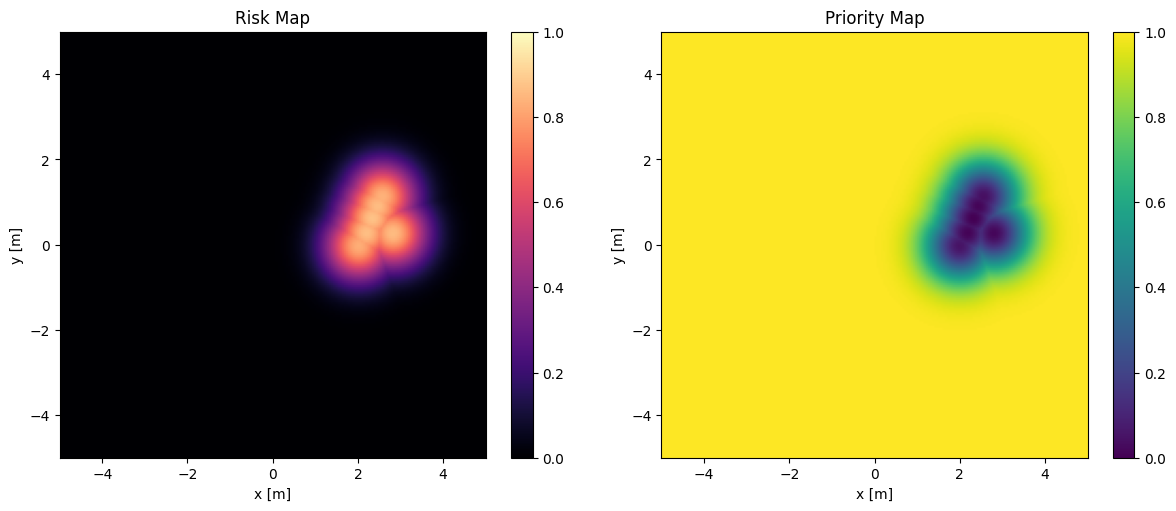

OccupancyGrid-like metadata:
{'resolution': 0.05, 'width': 200, 'height': 200, 'origin': {'position': {'x': -5.0, 'y': -5.0, 'z': 0.0}, 'orientation': {'x': 0.0, 'y': 0.0, 'z': 0.0, 'w': 1.0}}}
Serialized data length: 40000
First 20 values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
extent = [origin_x, origin_x + width * resolution, origin_y, origin_y + height * resolution]

im0 = axes[0].imshow(risk_map, origin="lower", extent=extent, vmin=0.0, vmax=1.0, cmap="magma")
axes[0].set_title("Risk Map")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(priority_map, origin="lower", extent=extent, vmin=0.0, vmax=1.0, cmap="viridis")
axes[1].set_title("Priority Map")
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("y [m]")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.show()


def make_occupancy_grid_like(risk: np.ndarray, resolution: float, origin_x: float, origin_y: float):
    # nav_msgs/OccupancyGrid는 row-major 1D 배열(data) 사용
    occ = np.clip(np.round(risk * 100.0), 0, 100).astype(np.int8)
    msg_like = {
        "header": {"frame_id": "map"},
        "info": {
            "resolution": resolution,
            "width": int(risk.shape[1]),
            "height": int(risk.shape[0]),
            "origin": {
                "position": {"x": origin_x, "y": origin_y, "z": 0.0},
                "orientation": {"x": 0.0, "y": 0.0, "z": 0.0, "w": 1.0},
            },
        },
        "data": occ.reshape(-1, order="C").tolist(),
    }
    return msg_like


occ_msg = make_occupancy_grid_like(risk_map, resolution, origin_x, origin_y)
print("OccupancyGrid-like metadata:")
print(occ_msg["info"])
print("Serialized data length:", len(occ_msg["data"]))
print("First 20 values:", occ_msg["data"][:20])

## 10) (옵션) YOLO 결과를 Detection 구조로 변환

카메라/이미지에서 YOLO를 돌려 Detection 리스트를 만들고, 같은 투영/리스크맵 루틴으로 연결할 때 사용한다.

In [21]:
# 선택 실행 셀: ultralytics 설치 및 모델 준비가 되어 있을 때만 사용
# from ultralytics import YOLO
# yolo_model = YOLO("yolo11n.pt")


def yolo_result_to_detections(result, person_class_id: int = 0, conf_th: float = 0.35) -> List[Detection]:
    out = []
    if result.boxes is None:
        return out

    boxes = result.boxes.xyxy.detach().cpu().numpy()
    confs = result.boxes.conf.detach().cpu().numpy()
    clss = result.boxes.cls.detach().cpu().numpy().astype(int)

    for (x1, y1, x2, y2), c, cls_id in zip(boxes, confs, clss):
        if cls_id != person_class_id or float(c) < conf_th:
            continue
        out.append(Detection(float(x1), float(y1), float(x2), float(y2), float(c), int(cls_id)))
    return out


print("Optional YOLO adapter ready")

Optional YOLO adapter ready


## 11) OpenCV 실시간 카메라 + 실시간 Risk Map 확인

카메라를 움직이면서 실시간으로 사람 검출과 risk map 누적/감쇠를 확인한다.

조작 키:
- `q`: 종료
- `w/s`: x 축 이동
- `a/d`: y 축 이동
- `j/l`: yaw 회전
- `r`: risk map 리셋

In [22]:
import cv2
from ultralytics import YOLO


def render_risk_map_bgr(risk: np.ndarray, robot_pose: RobotPose, spots, out_size=(640, 640)) -> np.ndarray:
    risk_u8 = np.clip(risk * 255.0, 0, 255).astype(np.uint8)
    heat = cv2.applyColorMap(risk_u8, cv2.COLORMAP_TURBO)

    # map frame 보정: numpy row 0이 아래로 보이도록 뒤집어 화면 표시를 직관화
    heat = cv2.flip(heat, 0)

    # 로봇 위치 그리기
    mx, my = world_to_map(robot_pose.x, robot_pose.y)
    my_vis = (height - 1) - my
    if 0 <= mx < width and 0 <= my_vis < height:
        cv2.circle(heat, (mx, my_vis), 3, (255, 255, 255), -1)
        hx = int(mx + 12 * math.cos(robot_pose.yaw))
        hy = int(my_vis - 12 * math.sin(robot_pose.yaw))
        cv2.arrowedLine(heat, (mx, my_vis), (hx, hy), (255, 255, 255), 1, tipLength=0.3)

    for mu_x, mu_y, _, _, _ in spots:
        sx, sy = world_to_map(mu_x, mu_y)
        sy_vis = (height - 1) - sy
        if 0 <= sx < width and 0 <= sy_vis < height:
            cv2.circle(heat, (sx, sy_vis), 3, (0, 0, 0), -1)

    heat = cv2.resize(heat, out_size, interpolation=cv2.INTER_NEAREST)
    cv2.putText(heat, "Risk Map (map frame)", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    return heat


def yolo_infer_persons(frame_bgr: np.ndarray, yolo_model, conf_th: float = 0.35):
    results = yolo_model.predict(source=frame_bgr, conf=conf_th, classes=[0], verbose=False)
    res = results[0]

    detections = yolo_result_to_detections(res, person_class_id=0, conf_th=conf_th)
    annotated = res.plot()

    return detections, annotated


# ===== 실시간 실행 설정 =====
VIDEO_SOURCE = 0
CONF_TH = 0.35
FRAME_SKIP = 2

# pose 수동 조작량
STEP_POS_M = 0.05
STEP_YAW_RAD = math.radians(3.0)

# 실시간 엔진
rt_engine = GaussianRiskMap(width, height, resolution, origin_x, origin_y)
robot_pose = RobotPose(0.0, 0.0, 0.0)

# 모델 로드
rt_model = YOLO("yolo11n.pt")

cap = cv2.VideoCapture(VIDEO_SOURCE)
if not cap.isOpened():
    print("카메라를 열 수 없음:", VIDEO_SOURCE)
else:
    frame_idx = 0
    last_spots = []

    while True:
        ret, frame = cap.read()
        if not ret:
            print("frame read failed")
            break

        frame_idx += 1
        annotated = frame.copy()

        if frame_idx % FRAME_SKIP == 0:
            dets, annotated = yolo_infer_persons(frame, rt_model, conf_th=CONF_TH)
            last_spots = rt_engine.update_frame(
                detections=dets,
                pose=robot_pose,
                sigma=gaussian_sigma_m,
                mode=gaussian_mode,
                decay_factor=decay,
            )
        else:
            rt_engine.decay_step(decay)

        # 카메라 영상에 상태 오버레이
        cv2.rectangle(annotated, (8, 8), (560, 92), (0, 0, 0), -1)
        cv2.putText(annotated, f"persons={len(last_spots)}  mode={gaussian_mode}  decay={decay}", (16, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(annotated, f"pose=({robot_pose.x:.2f}, {robot_pose.y:.2f}, yaw={math.degrees(robot_pose.yaw):.1f}deg)", (16, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 255, 200), 2, cv2.LINE_AA)

        risk_view = render_risk_map_bgr(rt_engine.risk_map, robot_pose, last_spots, out_size=(640, 640))

        cv2.imshow("YOLO Person Detection", annotated)
        cv2.imshow("Realtime Gaussian Risk Map", risk_view)

        key = cv2.waitKey(1) & 0xFF
        if key == ord("q"):
            break
        elif key == ord("w"):
            robot_pose.x += STEP_POS_M
        elif key == ord("s"):
            robot_pose.x -= STEP_POS_M
        elif key == ord("d"):
            robot_pose.y += STEP_POS_M
        elif key == ord("a"):
            robot_pose.y -= STEP_POS_M
        elif key == ord("j"):
            robot_pose.yaw += STEP_YAW_RAD
        elif key == ord("l"):
            robot_pose.yaw -= STEP_YAW_RAD
        elif key == ord("r"):
            rt_engine.risk_map.fill(0.0)

    cap.release()
    cv2.destroyAllWindows()
    print("done")

done
